<a href="https://colab.research.google.com/github/Alex-Devoid/Arizona-Sonora_Border_XYZ_Tiles/blob/master/Homework_4_Alex_Devoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4 - More practice summarizing data

**Author:** Alex Devoid

**Course:** ST 554

**Date:** Feburary 10, 2026  


## Purpose
"Practice summarizing data using `pandas` and `matplotlib` and do some more advanced function writing."

Homework 3 Code

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# read in the data

student_data = pd.read_csv('https://www4.stat.ncsu.edu/online/datasets/StudentData.txt', sep=';')

student_data.head()

# one-way contingency table
one_way_school = student_data['school'].value_counts()
one_way_school

# two-way contingency table
two_way_sex_school = pd.crosstab(student_data['sex'], student_data['school'])
two_way_sex_school

# three-way contingency table
three_way = pd.crosstab([student_data['school'], student_data['sex']], student_data['higher'])
three_way

# Conditional two-way table 1 (condition on school is GP):
gp_only = student_data.loc[student_data['school'] == 'GP']
cond_two_way_1 = pd.crosstab(gp_only['sex'], gp_only['higher'])
cond_two_way_1

# Conditional two-way table 2:
cond_two_way_2 = pd.crosstab([student_data['school'], student_data['sex']], student_data['higher'])
cond_two_way_2.loc['GP']


# Center and spread for three variables (age, absences, G3)
vars_3 = ['age', 'absences', 'G3']

for v in vars_3:
    s = student_data[v]
    print('\nVariable:', v)
    print('  mean  :', s.mean())
    print('  median:', s.median())
    print('  std   :', s.std())
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    print('  Q1    :', q1)
    print('  Q3    :', q3)
    print('  IQR   :', q3 - q1)


# Repeat center and spread after subsetting by sex (using .loc)
for sex in ['F', 'M']:
    sub = student_data.loc[student_data['sex'] == sex]
    print('\nSubset: sex =', sex)

    for v in vars_3:
        s = sub[v]
        print(' Variable:', v)
        print('  mean  :', s.mean())
        print('  median:', s.median())
        print('  std   :', s.std())
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        print('  Q1    :', q1)
        print('  Q3    :', q3)
        print('  IQR   :', q3 - q1)


# Center and spread across a single grouping variable:
mean_by_sex = student_data.groupby('sex')[vars_3].mean()
std_by_sex  = student_data.groupby('sex')[vars_3].std()
median_by_sex = student_data.groupby('sex')[vars_3].median()

q1_by_sex = student_data.groupby('sex')[vars_3].quantile(0.25)
q3_by_sex = student_data.groupby('sex')[vars_3].quantile(0.75)
iqr_by_sex = q3_by_sex - q1_by_sex
iqr_by_sex

print("Mean by sex:\n", mean_by_sex)
print("\nMedian by sex:\n", median_by_sex)
print("\nStd dev by sex:\n", std_by_sex)

# Center and spread across two grouping variables (school and sex):
mean_by_school_sex = student_data.groupby(['school', 'sex'])[vars_3].mean()
std_by_school_sex  = student_data.groupby(['school', 'sex'])[vars_3].std()
median_by_school_sex = student_data.groupby(['school', 'sex'])[vars_3].median()

print("Mean by school and sex:\n", mean_by_school_sex)
print("\nMedian by school and sex:\n", median_by_school_sex)
print("\nStd dev by school and sex:\n", std_by_school_sex)


# A correlation matrix between all of the numeric variables
numeric_vars = ['age', 'absences', 'G1', 'G2', 'G3']
corr_mat = student_data[numeric_vars].corr()
corr_mat





Variable: age
  mean  : 16.696202531645568
  median: 17.0
  std   : 1.2760427246056245
  Q1    : 16.0
  Q3    : 18.0
  IQR   : 2.0

Variable: absences
  mean  : 5.708860759493671
  median: 4.0
  std   : 8.003095687108177
  Q1    : 0.0
  Q3    : 8.0
  IQR   : 8.0

Variable: G3
  mean  : 10.415189873417722
  median: 11.0
  std   : 4.5814426109978434
  Q1    : 8.0
  Q3    : 14.0
  IQR   : 6.0

Subset: sex = F
 Variable: age
  mean  : 16.73076923076923
  median: 17.0
  std   : 1.2016958164931697
  Q1    : 16.0
  Q3    : 18.0
  IQR   : 2.0
 Variable: absences
  mean  : 6.216346153846154
  median: 4.0
  std   : 9.44581916132164
  Q1    : 0.0
  Q3    : 8.0
  IQR   : 8.0
 Variable: G3
  mean  : 9.966346153846153
  median: 10.0
  std   : 4.622338337431135
  Q1    : 8.0
  Q3    : 13.0
  IQR   : 5.0

Subset: sex = M
 Variable: age
  mean  : 16.657754010695186
  median: 16.0
  std   : 1.3561811038632565
  Q1    : 16.0
  Q3    : 18.0
  IQR   : 2.0
 Variable: absences
  mean  : 5.144385026737968
  

,age,absences,G1,G2,G3
age,1.000000,0.175230,-0.064081,-0.143474,-0.161579
absences,0.175230,1.000000,-0.031003,-0.031777,0.034247
G1,-0.064081,-0.031003,1.000000,0.852118,0.801468
G2,-0.143474,-0.031777,0.852118,1.000000,0.904868
G3,-0.161579,0.034247,0.801468,0.904868,1.000000


# Task 1

## Categorical variables

In [5]:
# comparing school vs sex

cat_tab = pd.crosstab(student_data["school"], student_data["sex"])
cat_tab


sex,F,M
school,,
GP,183,166
MS,25,21


### Stacked bar plot

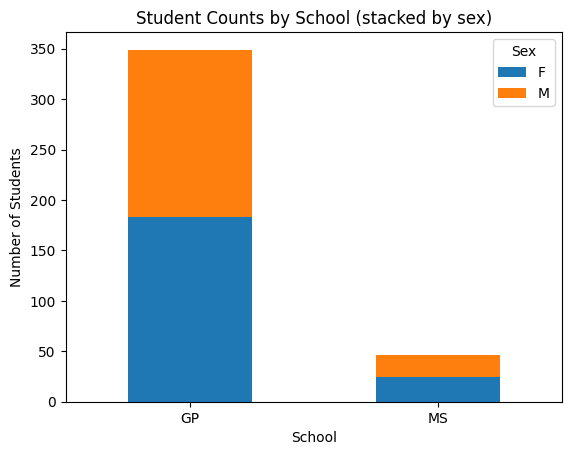

In [6]:

cat_tab.plot.bar(stacked=True, rot=0)
plt.xlabel("School")
plt.ylabel("Number of Students")
plt.title("Student Counts by School (stacked by sex)")
plt.legend(title="Sex")
plt.show()


### Side-by-side bar plot

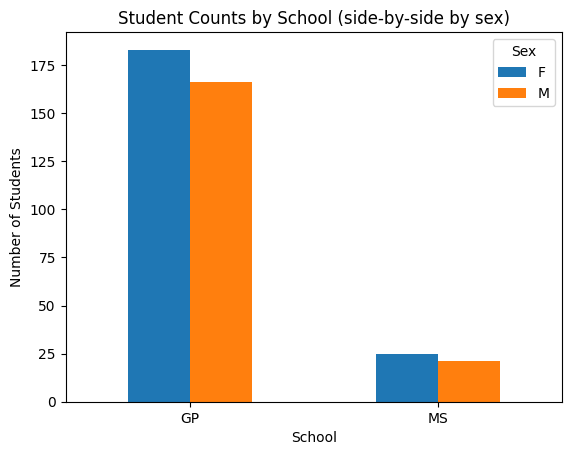

In [7]:
cat_tab.plot.bar(rot=0)
plt.xlabel("School")
plt.ylabel("Number of Students")
plt.title("Student Counts by School (side-by-side by sex)")
plt.legend(title="Sex")
plt.show()


# Numeric variables (and across groups)


In [8]:
# Convenience series for grouping by sex
g3_f = student_data.loc[student_data["sex"] == "F", "G3"]
g3_m = student_data.loc[student_data["sex"] == "M", "G3"]

abs_f = student_data.loc[student_data["sex"] == "F", "absences"]
abs_m = student_data.loc[student_data["sex"] == "M", "absences"]


### Histogram of G3 across sex

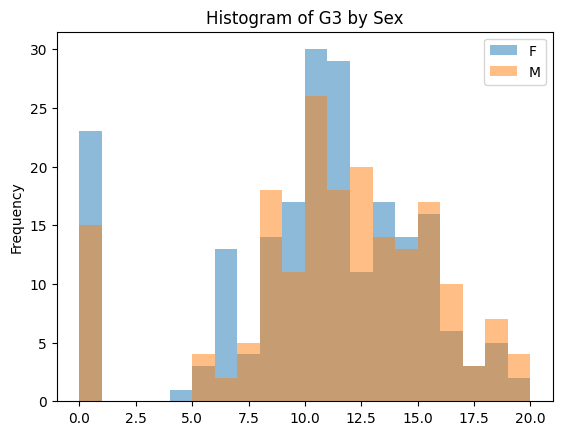

In [9]:

bins = list(range(0, 21))  # grades are 0-20

g3_f.plot.hist(bins=bins, alpha=0.5, label="F", title="Histogram of G3 by Sex").set(xlabel="G3 (Final Grade)")
g3_m.plot.hist(bins=bins, alpha=0.5, label="M")
plt.ylabel("Frequency")
plt.legend()
plt.show()



## Histogram of absences across sex (overlayed with alpha)

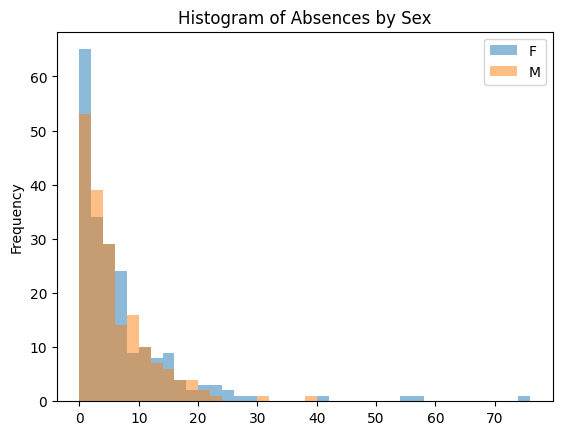

In [10]:

# covering the range with max()
max_abs = int(student_data["absences"].max())
bins_abs = list(range(0, max_abs + 2, 2))

abs_f.plot.hist(bins=bins_abs, alpha=0.5, label="F", title="Histogram of Absences by Sex")     .set(xlabel="Absences")
abs_m.plot.hist(bins=bins_abs, alpha=0.5, label="M")
plt.ylabel("Frequency")
plt.legend()
plt.show()



## Kernel density plot of G3 across sex

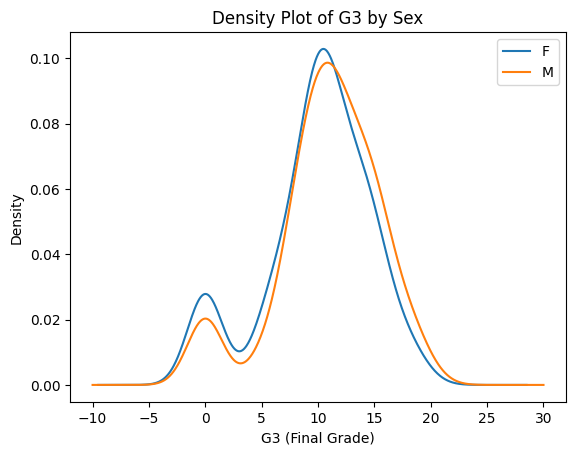

In [11]:

g3_f.plot.density(label="F", title="Density Plot of G3 by Sex").set(xlabel="G3 (Final Grade)")
g3_m.plot.density(label="M")
plt.ylabel("Density")
plt.legend()
plt.show()



### Kernel density plot of absences across sex

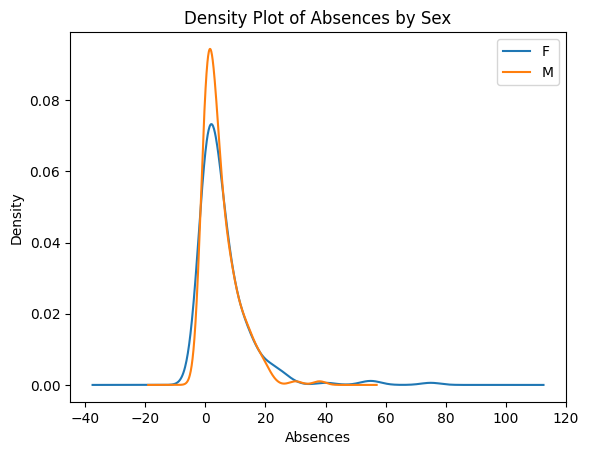

In [12]:

abs_f.plot.density(label="F", title="Density Plot of Absences by Sex").set(xlabel="Absences")
abs_m.plot.density(label="M")
plt.ylabel("Density")
plt.legend()
plt.show()




### Boxplot of G3 across sex

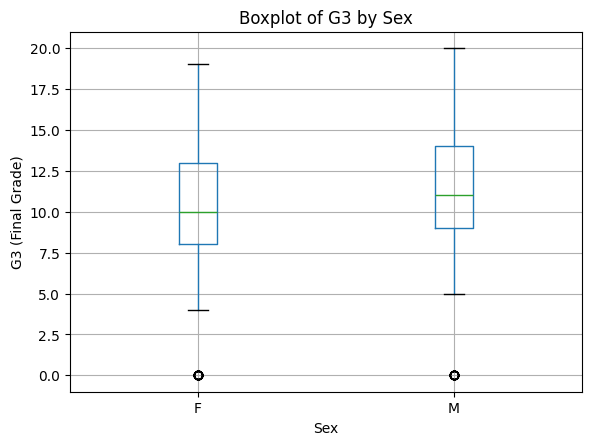

In [13]:

student_data.boxplot(column=["G3"], by="sex")
plt.xlabel("Sex")
plt.ylabel("G3 (Final Grade)")
plt.title("Boxplot of G3 by Sex")
plt.suptitle("")
plt.show()


### Boxplot of absences across sex

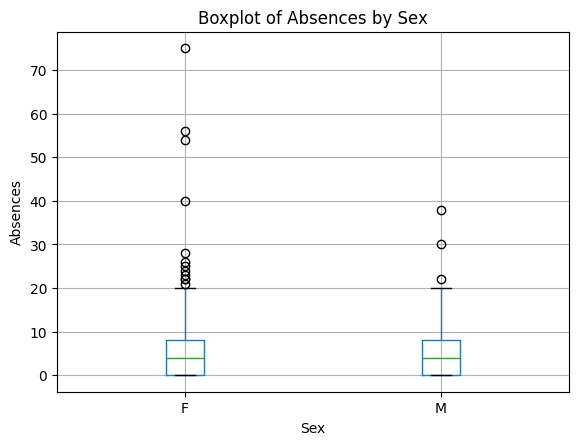

In [14]:

student_data.boxplot(column=["absences"], by="sex")
plt.xlabel("Sex")
plt.ylabel("Absences")
plt.title("Boxplot of Absences by Sex")
plt.suptitle("")
plt.show()



## Create two scatterplots relating G3 to other numeric variables

### Scatterplot 1: G3 vs G2, colored by school

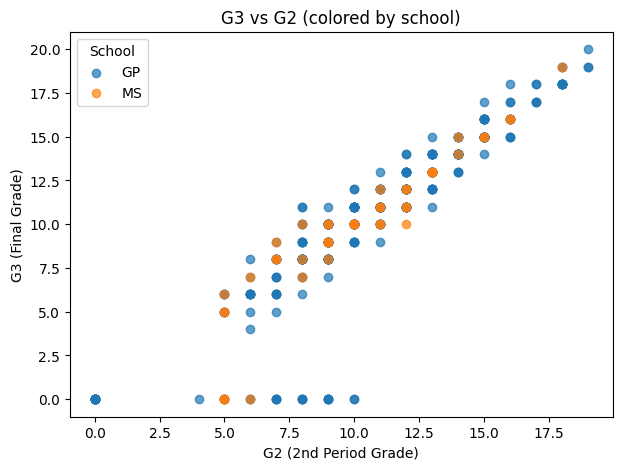

In [15]:

plt.figure(figsize=(7, 5))
for school in student_data["school"].unique():
    sub = student_data.loc[student_data["school"] == school]
    plt.scatter(sub["G2"], sub["G3"], label=school, alpha=0.7)

plt.xlabel("G2 (2nd Period Grade)")
plt.ylabel("G3 (Final Grade)")
plt.title("G3 vs G2 (colored by school)")
plt.legend(title="School")
plt.show()


### Scatterplot 2: G3 vs absences, colored by sex



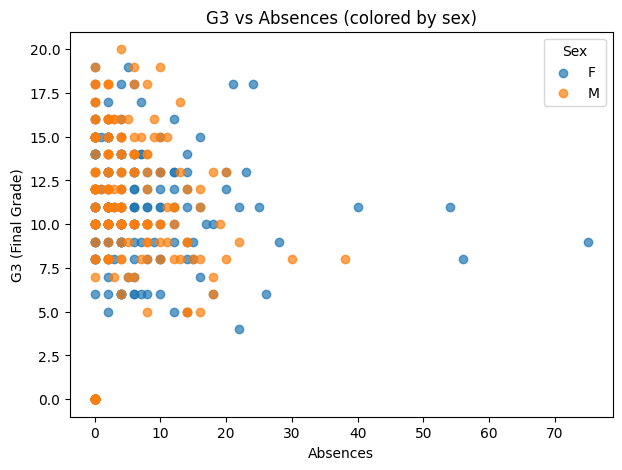

In [31]:

plt.figure(figsize=(7, 5))
for sex in student_data["sex"].unique():
    sub = student_data.loc[student_data["sex"] == sex]
    plt.scatter(sub["absences"], sub["G3"], label=sex, alpha=0.7)

plt.xlabel("Absences")
plt.ylabel("G3 (Final Grade)")
plt.title("G3 vs Absences (colored by sex)")
plt.legend(title="Sex")
plt.show()

# Plotting the NFL Box Score Data

## Task 1

  
Each row is a game. The final scores (`AFinal`, `HFinal`) are the main outcomes we’ll summarize and plot.

In [16]:
nfl_url = "https://www4.stat.ncsu.edu/~online/datasets/scoresFull.csv"
nfl_data = pd.read_csv(nfl_url)

nfl_data.head()

,week,date,day,season,awayTeam,AQ1,AQ2,AQ3,AQ4,AOT,...,homeFumLost,homeNumPen,homePenYds,home3rdConv,home3rdAtt,home4thConv,home4thAtt,homeTOP,HminusAScore,homeSpread
0,1,5-Sep,Thu,2002,San Francisco 49ers,3,0,7,6,-1,...,0,10,80,4,8,0,1,32.47,-3,-4.0
1,1,8-Sep,Sun,2002,Minnesota Vikings,3,17,0,3,-1,...,1,4,33,2,6,0,0,28.48,4,4.5
2,1,8-Sep,Sun,2002,New Orleans Saints,6,7,7,0,6,...,0,8,85,1,6,0,1,31.48,-6,6.0
3,1,8-Sep,Sun,2002,New York Jets,0,17,3,11,6,...,1,10,82,4,8,2,2,39.13,-6,-3.0
4,1,8-Sep,Sun,2002,Arizona Cardinals,10,3,3,7,-1,...,0,7,56,6,10,1,2,34.40,8,6.0


### Convert to category type

"Convert the homeTeam, awayTeam, day, stadium, startTime, toss, roof, and surface to category
type variables."

In [17]:

cat_cols = ["homeTeam", "awayTeam", "day", "stadium", "startTime", "toss", "roof", "surface"]
for c in cat_cols:
    nfl_data[c] = nfl_data[c].astype("category")

nfl_data[cat_cols].dtypes


,0
homeTeam,category
awayTeam,category
day,category
stadium,category
startTime,category
toss,category
roof,category
surface,category


## Task 2 Summarie the data

Keep only weeks 1 through 17 (regular season)

In [18]:
nfl_data["week_num"] = pd.to_numeric(nfl_data["week"], errors="coerce")
#  remove any data where the week is not 1 through 17.
nfl_reg = nfl_data.loc[nfl_data["week_num"].between(1, 17)].copy()


print("Original rows:", nfl_data.shape[0])
print("Weeks 1-17 rows:", nfl_reg.shape[0])

Original rows: 3471
Regular season rows: 3328


## Summarize variables grouped by season and week, season alone, and week alone



In [19]:
nfl_reg["totalPoints"] = nfl_reg["AFinal"] + nfl_reg["HFinal"]
nfl_reg["totalYds"] = nfl_reg["AtotalYds"] + nfl_reg["HtotalYds"]

# Looking at pass INTs and fumbles for both teams
nfl_reg["turnovers"] = (
    nfl_reg["awayPassInt"] + nfl_reg["awayFumLost"] +
    nfl_reg["homePassInt"] + nfl_reg["homeFumLost"]
)

nfl_reg[["totalPoints", "totalYds", "turnovers"]].head()

,totalPoints,totalYds,turnovers
0,29,640,4
1,50,736,5
2,46,701,2
3,68,650,4
4,54,699,2


#### Grouped by season and week


In [20]:
season_week_summary = nfl_reg.groupby(["season", "week_num"])[["totalPoints","totalYds","turnovers"]].agg(["mean","std","count"])


season_week_summary.head()

totalPoints                     totalYds                    \
                   mean        std count        mean         std count   
season week                                                              
2002   1      49.250000  16.874043    16  658.625000  102.049579    16   
       10     46.071429  14.860709    14  727.714286  152.215651    14   
       11     40.937500   8.520319    16  643.437500  115.132949    16   
       12     42.187500  12.150274    16  687.125000  137.090177    16   
       13     44.062500  14.708133    16  653.312500  121.113566    16   

            turnovers                  
                 mean       std count  
season week                            
2002   1       3.1875  1.759498    16  
       10      3.5000  1.698416    14  
       11      3.0625  1.569235    16  
       12      3.7500  2.294922    16  
       13      4.0625  2.205108    16

#### Grouped by season alone


In [21]:
# Grouped by season alone
season_summary = nfl_reg.groupby("season")[["totalPoints", "totalYds", "turnovers"]].agg(["mean", "std", "count"])

season_summary.head()


totalPoints                     totalYds                   turnovers  \
              mean        std count        mean         std count      mean   
season                                                                        
2002     43.347656  14.558342   256  656.718750  120.227688   256  3.621094   
2003     41.664062  13.960323   256  636.597656  110.689099   256  3.558594   
2004     42.968750  15.046301   256  654.320312  132.539890   256  3.531250   
2005     41.234375  13.182570   256  631.839844  109.791361   256  3.500000   
2006     41.316406  14.215343   256  644.226562  114.095090   256  3.503906   

                        
             std count  
season                  
2002    1.826006   256  
2003    1.858864   256  
2004    1.825473   256  
2005    1.948353   256  
2006    1.880755   256

#### Grouped by week alone (across all seasons)



In [22]:

week_summary = nfl_reg.groupby("week_num")[["totalPoints","totalYds","turnovers"]].agg(["mean","std","count"])


week_summary.head()


totalPoints                     totalYds                   turnovers  \
            mean        std count        mean         std count      mean   
week                                                                        
1      41.855769  13.973694   208  651.625000  116.679973   208  3.399038   
10     44.526882  14.454096   186  665.467742  133.416647   186  3.440860   
11     42.174129  14.262346   201  667.393035  117.168809   201  3.328358   
12     44.385366  15.212958   205  672.575610  130.544450   205  3.443902   
13     43.639423  14.130167   208  669.331731  120.222823   208  3.557692   

                      
           std count  
week                  
1     1.817627   208  
10    1.839285   186  
11    1.703421   201  
12    1.943573   205  
13    1.910191   208

### Plots over time

#### Plot 1: Mean total points by week (averaged across all seasons)



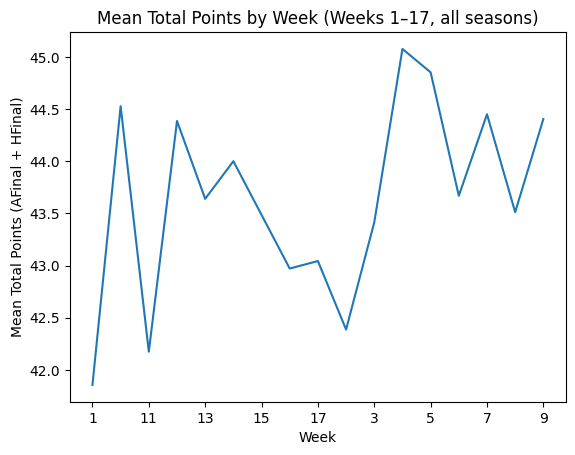

In [23]:

nfl_reg.groupby("week")["totalPoints"].mean().plot()
plt.xlabel("Week")
plt.ylabel("Mean Total Points (AFinal + HFinal)")
plt.title("Mean Total Points by Week (Weeks 1–17, all seasons)")
plt.show()


#### Plot 2: Mean total points by season

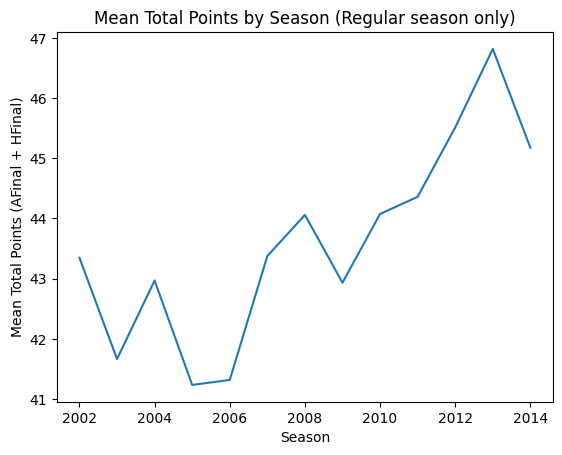

In [24]:
# Plot 2: Mean total points by season
nfl_reg.groupby("season")["totalPoints"].mean().plot()
plt.xlabel("Season")
plt.ylabel("Mean Total Points (AFinal + HFinal)")
plt.title("Mean Total Points by Season (Weeks 1–17 only)")
plt.show()


#### Plot 3: Mean total points by (season, week) as multiple lines (one line per season)



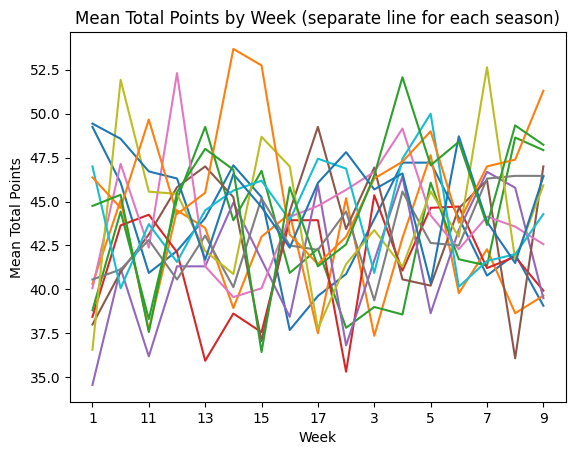

In [25]:
# plot 3
sw = nfl_reg.groupby(["season", "week"])["totalPoints"].mean().reset_index()
pivot = sw.pivot(index="week", columns="season", values="totalPoints")
pivot.plot(legend=False)
plt.xlabel("Week")
plt.ylabel("Mean Total Points")
plt.title("Mean Total Points by Week (separate line for each season)")
plt.show()

## Function writing for plotting

In [26]:
import time
from functools import wraps

def timeit(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        elapsed = end - start
        print(f"{func.__name__} ran in {elapsed:.6f} seconds")
        return result
    return wrapper


In [27]:
@timeit
def plot_group_stat(df: pd.DataFrame,
                    value_col: str,
                    group_col: str,
                    stat: str = "mean",
                    title: None | str = None):
    """
    Plot a statistic of a numeric column grouped by one grouping column.

    Args:
        df (pd.DataFrame): Football dataset
        value_col (str): Numeric column to summarize
        group_col (str): Grouping column
        stat (str): One of 'mean', 'median', 'std', 'sum', 'count'. Default is 'mean'
        title (None | str): plot title or leave blank
    """
    allowed = ["mean", "median", "std", "sum", "count"]
    if stat not in allowed:
        print(" must be one of the following:", allowed)
        return

    summary = df.groupby(group_col)[value_col].agg(stat)

    summary.plot()
    plt.xlabel(group_col)
    plt.ylabel(f"{stat}({value_col})")
    if title is None:
        plt.title(f"{stat} of {value_col} by {group_col}")
    else:
        plt.title(title)
    plt.show()


### Function run 1


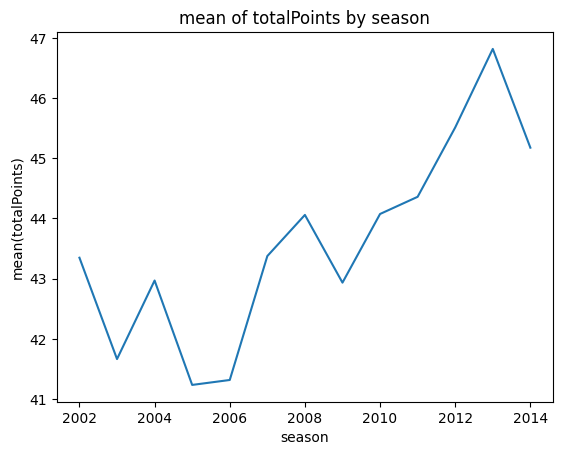

plot_group_stat ran in 0.158747 seconds


In [28]:
plot_group_stat(nfl_reg, value_col="totalPoints", group_col="season", stat="mean")

#### Function run 2


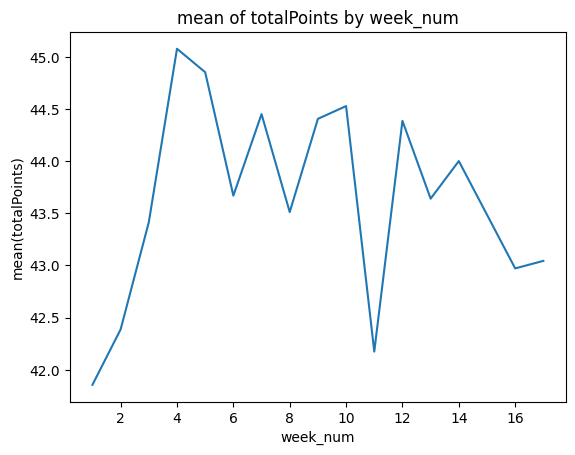

plot_group_stat ran in 0.228881 seconds


In [32]:
plot_group_stat(nfl_reg, value_col="totalPoints", group_col="week_num", stat="mean")


#### Function run 3


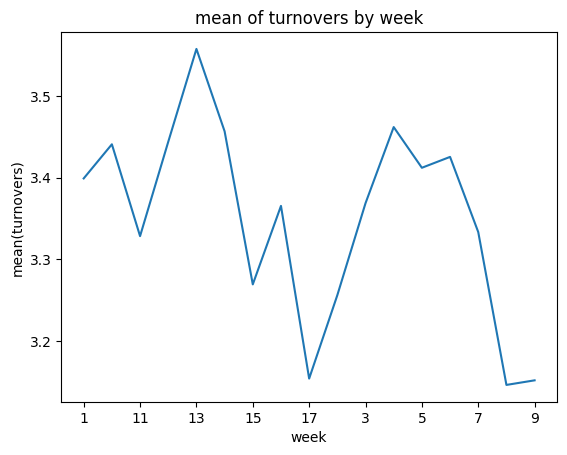

plot_group_stat ran in 0.135509 seconds


In [30]:
plot_group_stat(nfl_reg, value_col="turnovers", group_col="week", stat="mean")